# Cardivascular Disease Prediction

The aim of this project to predict the occurence of cardiovascular disease in patients based on their medical records. The project analyzes the patients medical records and medical history to calculate the probability of the occurence of cardiovascular disease in the patient. 

### Data Dictionary

| Feature | Description |
| --- | --- |
| General Health |  general health condition|
| Checkup| Last checkup |
| Excersise | Does the patient excersise |
|Heart Disease | Does the patient have heart disease |
|Skin Cancer | Does the patient have skin cancer |
| Other Cancer | Does the patient have other cancer |
| Depression | Does the patient have depression |
| Diabetes | Does the patient have diabetes |
|Arthritis | Does the patient have arthritis |
|Sex| patient's gender|
|Age-Category| patient's age category|
|BMI| patient's BMI|
|Smoking History| patient's smoking history|
|Alcohol Consumption| patient's alcohol consumption|
|Fruit Consumption| patient's fruit consumption|
|Green Vegetable Consumption| patient's green vegetable consumption|
|Fried Potato Consumption| patient's fried potato consumption|

In [2]:
#importing the libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df=pd.read_csv('CVD_cleaned.csv')
df.head()

,General_Health,Checkup,Exercise,Heart_Disease,Skin_Cancer,Other_Cancer,Depression,Diabetes,Arthritis,Sex,Age_Category,Height_(cm),Weight_(kg),BMI,Smoking_History,Alcohol_Consumption,Fruit_Consumption,Green_Vegetables_Consumption,FriedPotato_Consumption
0,Poor,Within the past 2 years,No,No,No,No,No,No,Yes,Female,70-74,150.0,32.66,14.54,Yes,0.0,30.0,16.0,12.0
1,Very Good,Within the past year,No,Yes,No,No,No,Yes,No,Female,70-74,165.0,77.11,28.29,No,0.0,30.0,0.0,4.0
2,Very Good,Within the past year,Yes,No,No,No,No,Yes,No,Female,60-64,163.0,88.45,33.47,No,4.0,12.0,3.0,16.0
3,Poor,Within the past year,Yes,Yes,No,No,No,Yes,No,Male,75-79,180.0,93.44,28.73,No,0.0,30.0,30.0,8.0
4,Good,Within the past year,No,No,No,No,No,No,No,Male,80+,191.0,88.45,24.37,Yes,0.0,8.0,4.0,0.0


In [4]:
df.shape

(308854, 19)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 308854 entries, 0 to 308853
Data columns (total 19 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   General_Health                308854 non-null  object 
 1   Checkup                       308854 non-null  object 
 2   Exercise                      308854 non-null  object 
 3   Heart_Disease                 308854 non-null  object 
 4   Skin_Cancer                   308854 non-null  object 
 5   Other_Cancer                  308854 non-null  object 
 6   Depression                    308854 non-null  object 
 7   Diabetes                      308854 non-null  object 
 8   Arthritis                     308854 non-null  object 
 9   Sex                           308854 non-null  object 
 10  Age_Category                  308854 non-null  object 
 11  Height_(cm)                   308854 non-null  float64
 12  Weight_(kg)                   308854 non-nul

In [7]:
df.isnull().sum()

General_Health                  0
Checkup                         0
Exercise                        0
Heart_Disease                   0
Skin_Cancer                     0
Other_Cancer                    0
Depression                      0
Diabetes                        0
Arthritis                       0
Sex                             0
Age_Category                    0
Height_(cm)                     0
Weight_(kg)                     0
BMI                             0
Smoking_History                 0
Alcohol_Consumption             0
Fruit_Consumption               0
Green_Vegetables_Consumption    0
FriedPotato_Consumption         0
dtype: int64

In [10]:
df.drop(columns=['Weight_(kg)','Height_(cm)'], inplace=True)

In [11]:
df

,General_Health,Checkup,Exercise,Heart_Disease,Skin_Cancer,Other_Cancer,Depression,Diabetes,Arthritis,Sex,Age_Category,BMI,Smoking_History,Alcohol_Consumption,Fruit_Consumption,Green_Vegetables_Consumption,FriedPotato_Consumption
0,Poor,Within the past 2 years,No,No,No,No,No,No,Yes,Female,70-74,14.54,Yes,0.0,30.0,16.0,12.0
1,Very Good,Within the past year,No,Yes,No,No,No,Yes,No,Female,70-74,28.29,No,0.0,30.0,0.0,4.0
2,Very Good,Within the past year,Yes,No,No,No,No,Yes,No,Female,60-64,33.47,No,4.0,12.0,3.0,16.0
3,Poor,Within the past year,Yes,Yes,No,No,No,Yes,No,Male,75-79,28.73,No,0.0,30.0,30.0,8.0
4,Good,Within the past year,No,No,No,No,No,No,No,Male,80+,24.37,Yes,0.0,8.0,4.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
308849,Very Good,Within the past year,Yes,No,No,No,No,No,No,Male,25-29,29.05,No,4.0,30.0,8.0,0.0
308850,Fair,Within the past 5 years,Yes,No,No,No,No,Yes,No,Male,65-69,21.48,No,8.0,15.0,60.0,4.0
308851,Very Good,5 or more years ago,Yes,No,No,No,Yes,"Yes, but female told only during pregnancy",No,Female,30-34,24.69,Yes,4.0,40.0,8.0,4.0
308852,Very Good,Within the past year,Yes,No,No,No,No,No,No,Male,65-69,23.73,No,3.0,30.0,12.0,0.0


In [12]:
for i in df.columns:
    print(i, df[i].unique())
    

General_Health ['Poor' 'Very Good' 'Good' 'Fair' 'Excellent']
Checkup ['Within the past 2 years' 'Within the past year' '5 or more years ago'
 'Within the past 5 years' 'Never']
Exercise ['No' 'Yes']
Heart_Disease ['No' 'Yes']
Skin_Cancer ['No' 'Yes']
Other_Cancer ['No' 'Yes']
Depression ['No' 'Yes']
Diabetes ['No' 'Yes' 'No, pre-diabetes or borderline diabetes'
 'Yes, but female told only during pregnancy']
Arthritis ['Yes' 'No']
Sex ['Female' 'Male']
Age_Category ['70-74' '60-64' '75-79' '80+' '65-69' '50-54' '45-49' '18-24' '30-34'
 '55-59' '35-39' '40-44' '25-29']
BMI [14.54 28.29 33.47 ... 63.83 19.09 56.32]
Smoking_History ['Yes' 'No']
Alcohol_Consumption [ 0.  4.  3.  8. 30.  2. 12.  1.  5. 10. 20. 17. 16.  6. 25. 28. 15.  7.
  9. 24. 11. 29. 27. 14. 21. 23. 18. 26. 22. 13. 19.]
Fruit_Consumption [ 30.  12.   8.  16.   2.   1.  60.   0.   7.   5.   3.   6.  90.  28.
  20.   4.  80.  24.  15.  10.  25.  14. 120.  32.  40.  17.  45. 100.
   9.  99.  96.  35.  50.  56.  48.  27.  7

In [13]:
df['Diabetes'] = df['Diabetes'].map({'No, pre-diabetes or borderline diabetes': 'Pre-Diabetes' ,'Yes, but female told only during pregnancy' : 'Gestational Diabetes', 'Yes': 'Yes', 'No': 'No'})

In [15]:
df['Diabetes'].unique()

array(['No', 'Yes', 'Pre-Diabetes', 'Gestational Diabetes'], dtype=object)

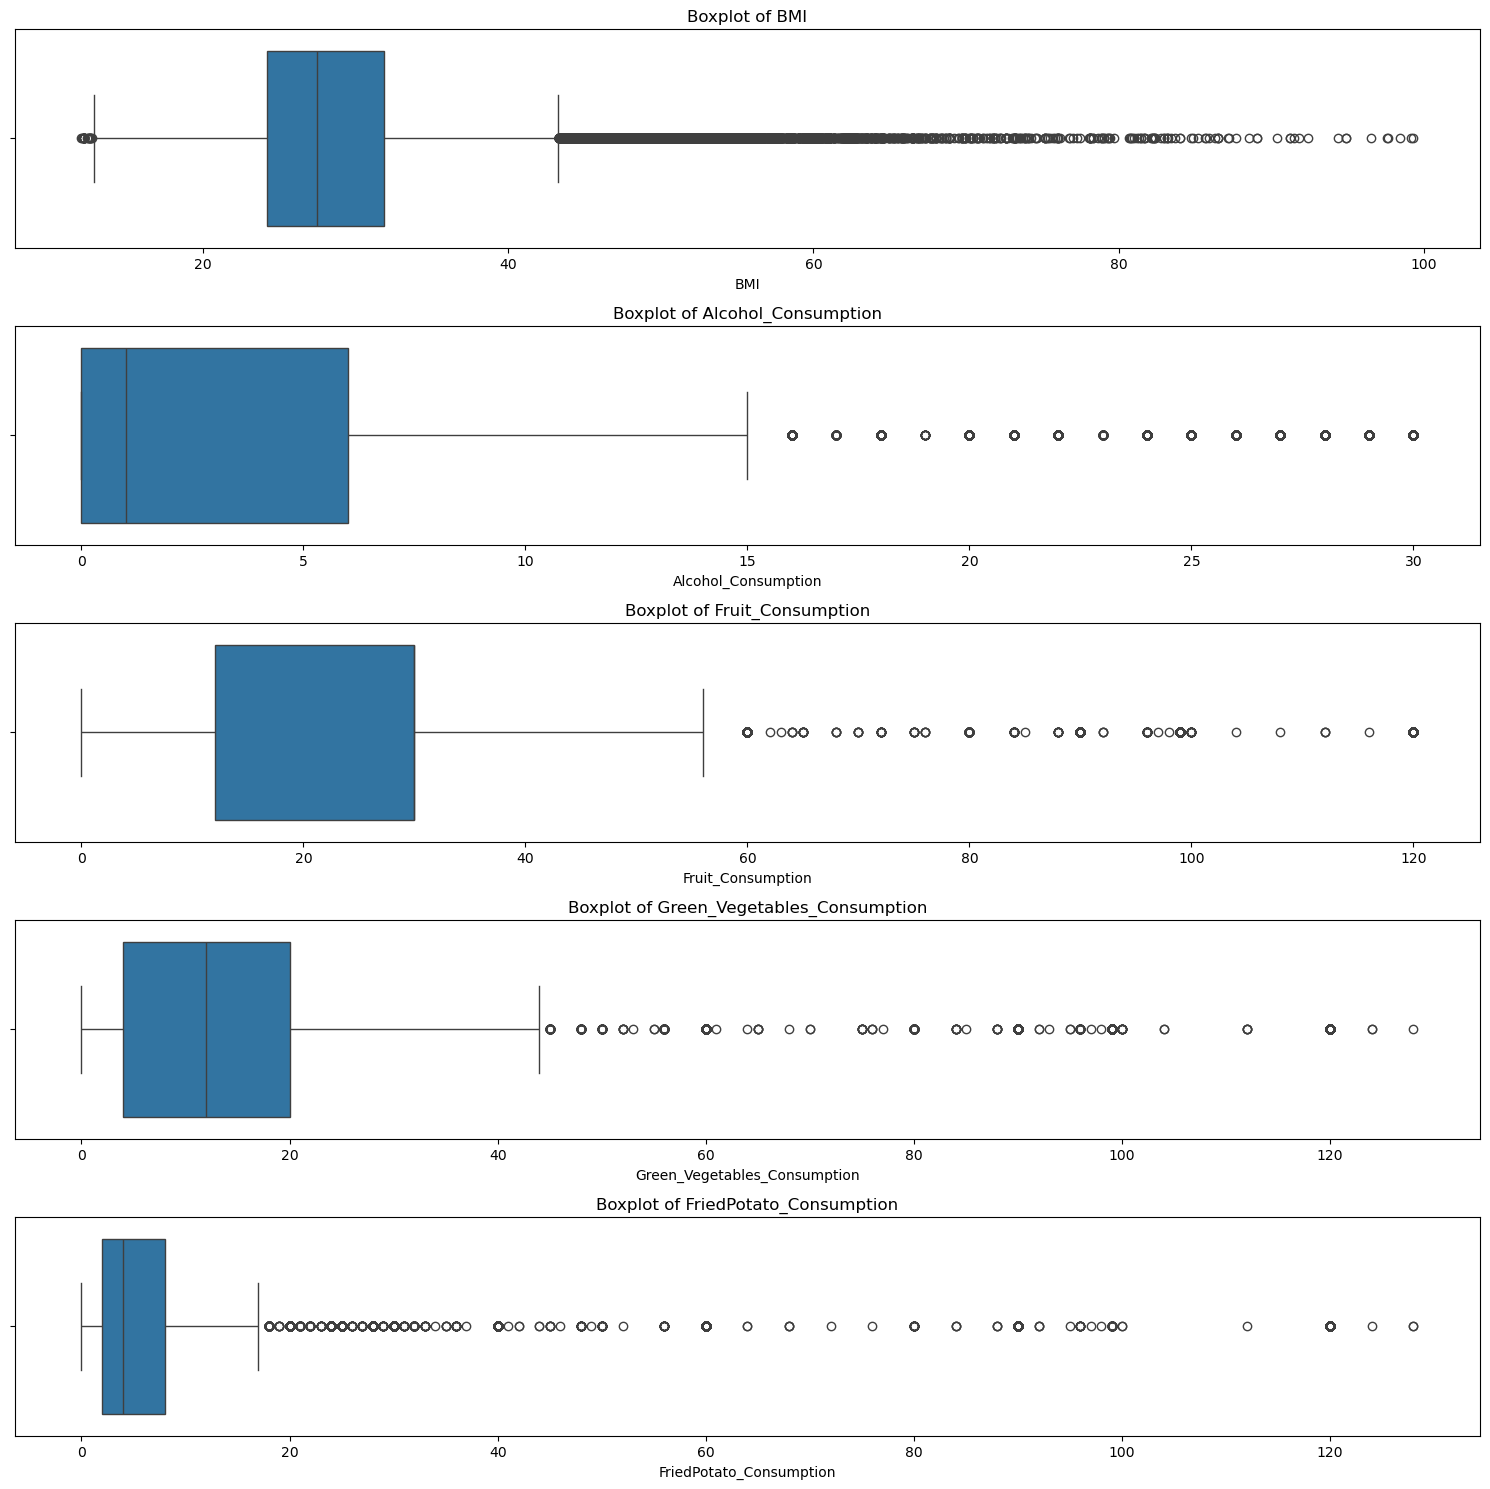

In [16]:
# Select only numeric columns
num_cols = df.select_dtypes(include='number').columns

# Create subplots
plt.figure(figsize=(15, len(num_cols)*3))

for i, col in enumerate(num_cols, 1):
    plt.subplot(len(num_cols), 1, i)
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')

plt.tight_layout()
plt.show()

In [18]:
q1= df[num_cols].quantile(0.25)
q3= df[num_cols].quantile(0.75)
iqr= q3-q1
threshold=1.5

index= np.where((df[num_cols]<(q1- threshold*iqr)) | (df[num_cols]>(q3+ threshold*iqr)))[0]
df=df.drop(df.index[index])

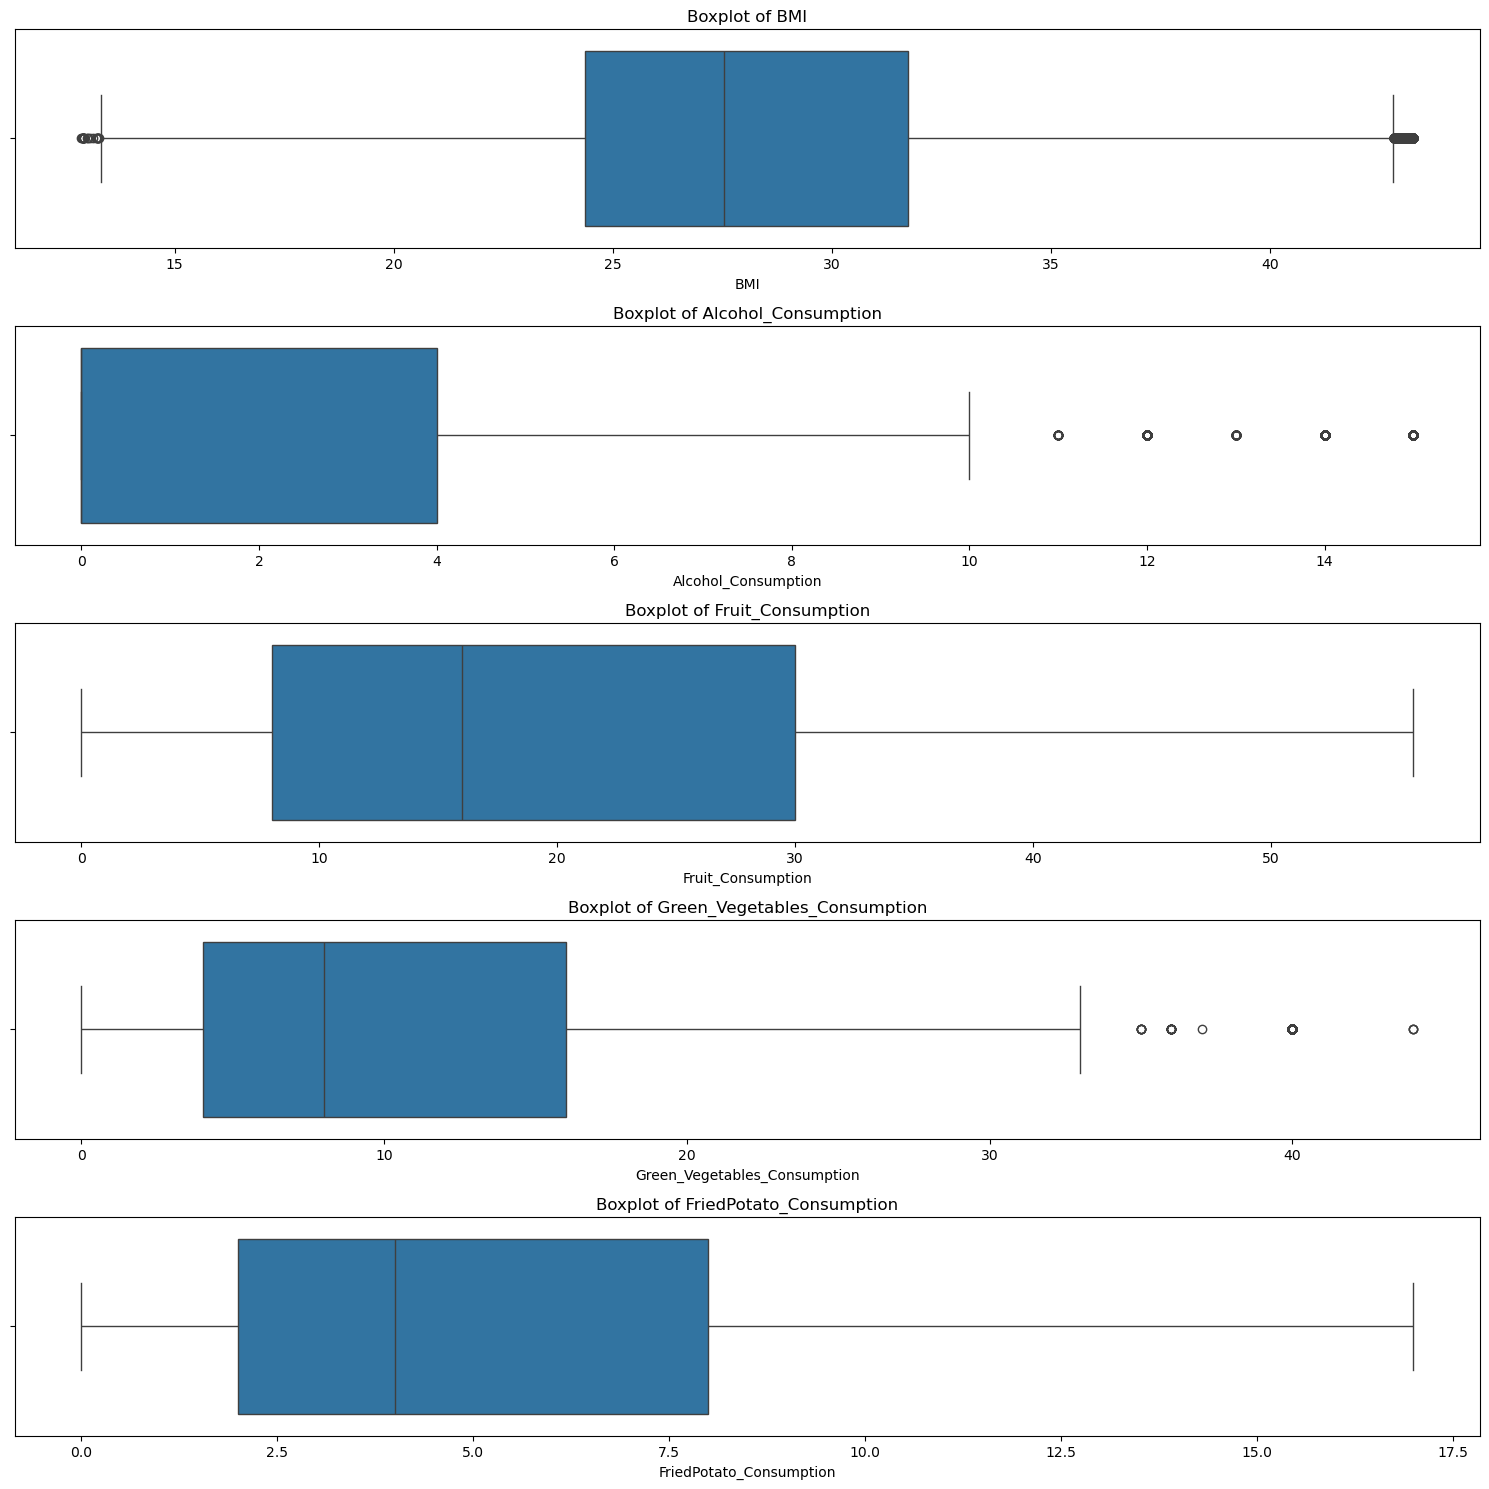

In [19]:
plt.figure(figsize=(15, len(num_cols)*3))

for i, col in enumerate(num_cols, 1):
    plt.subplot(len(num_cols), 1, i)
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')

plt.tight_layout()
plt.show()

In [20]:
df.describe()

,BMI,Alcohol_Consumption,Fruit_Consumption,Green_Vegetables_Consumption,FriedPotato_Consumption
count,186777.000000,186777.000000,186777.000000,186777.000000,186777.000000
mean,28.303577,2.505287,18.446104,11.893440,4.899565
std,5.433758,3.777076,10.898445,9.604871,4.261893
min,12.870000,0.000000,0.000000,0.000000,0.000000
25%,24.370000,0.000000,8.000000,4.000000,2.000000
50%,27.550000,0.000000,16.000000,8.000000,4.000000
75%,31.750000,4.000000,30.000000,16.000000,8.000000
max,43.280000,15.000000,56.000000,44.000000,17.000000


In [21]:
df.head()

,General_Health,Checkup,Exercise,Heart_Disease,Skin_Cancer,Other_Cancer,Depression,Diabetes,Arthritis,Sex,Age_Category,BMI,Smoking_History,Alcohol_Consumption,Fruit_Consumption,Green_Vegetables_Consumption,FriedPotato_Consumption
0,Poor,Within the past 2 years,No,No,No,No,No,No,Yes,Female,70-74,14.54,Yes,0.0,30.0,16.0,12.0
1,Very Good,Within the past year,No,Yes,No,No,No,Yes,No,Female,70-74,28.29,No,0.0,30.0,0.0,4.0
2,Very Good,Within the past year,Yes,No,No,No,No,Yes,No,Female,60-64,33.47,No,4.0,12.0,3.0,16.0
3,Poor,Within the past year,Yes,Yes,No,No,No,Yes,No,Male,75-79,28.73,No,0.0,30.0,30.0,8.0
4,Good,Within the past year,No,No,No,No,No,No,No,Male,80+,24.37,Yes,0.0,8.0,4.0,0.0


C:\Users\welcome\AppData\Local\Temp\ipykernel_21508\436134082.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Age_Category', data=df, ax=ax[1], palette='Set2').set_title('Age_Distribution')
C:\Users\welcome\AppData\Local\Temp\ipykernel_21508\436134082.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1].set_xticklabels(ax[1].get_xticklabels(),rotation=90, ha='right')


Text(0.5, 1.0, 'BMI_ Distribution')

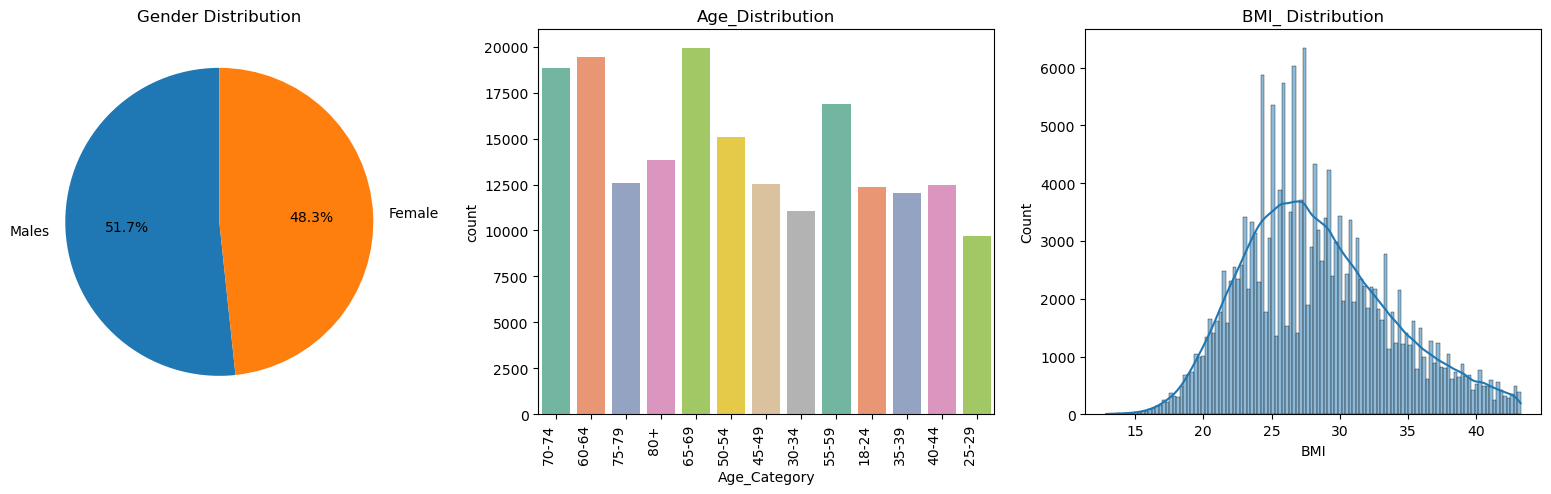

In [34]:
fig,ax = plt.subplots(1,3,figsize=(20,5))
ax[0].pie(df['Sex'].value_counts(), labels=['Males','Female'], startangle=90, autopct='%1.1f%%')
ax[0].set_title('Gender Distribution')
sns.countplot(x='Age_Category', data=df, ax=ax[1], palette='Set2').set_title('Age_Distribution')
ax[1].set_xticklabels(ax[1].get_xticklabels(),rotation=90, ha='right')
sns.histplot(x='BMI', data=df, ax=ax[2], kde=True).set_title('BMI_ Distribution')

The above three graphs explains the patient demographics in the dataset. From the pie chart, it is clear that majority of ptients are male with 52% followed by females with 48%. Looking at the age distribution, we came to know that majority of patients are older than 45 years of age, this means that the dataset is skewed towards older patients. The histogram of BMI shows that the BMI of majority of patients is between 25 to 30. This means that majority of patients are overweight. Therefore, I build a hypothesis that the patients with higher BMI are more likely to have cardiovascular disease.

In [36]:
df.head()

,General_Health,Checkup,Exercise,Heart_Disease,Skin_Cancer,Other_Cancer,Depression,Diabetes,Arthritis,Sex,Age_Category,BMI,Smoking_History,Alcohol_Consumption,Fruit_Consumption,Green_Vegetables_Consumption,FriedPotato_Consumption
0,Poor,Within the past 2 years,No,No,No,No,No,No,Yes,Female,70-74,14.54,Yes,0.0,30.0,16.0,12.0
1,Very Good,Within the past year,No,Yes,No,No,No,Yes,No,Female,70-74,28.29,No,0.0,30.0,0.0,4.0
2,Very Good,Within the past year,Yes,No,No,No,No,Yes,No,Female,60-64,33.47,No,4.0,12.0,3.0,16.0
3,Poor,Within the past year,Yes,Yes,No,No,No,Yes,No,Male,75-79,28.73,No,0.0,30.0,30.0,8.0
4,Good,Within the past year,No,No,No,No,No,No,No,Male,80+,24.37,Yes,0.0,8.0,4.0,0.0


### General Health and Last Checkup

<Axes: xlabel='General_Health', ylabel='count'>

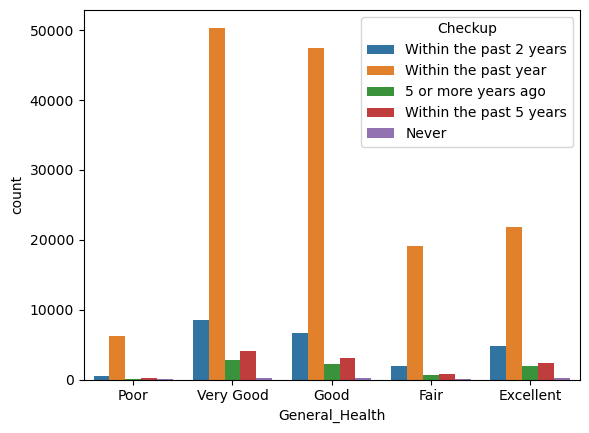

In [37]:
sns.countplot(x='General_Health', data=df, hue='Checkup')

  According to this graph most of the people are either in good or very good health, followed by excellent general health. This means that most of the people in the dataset are healthy. Very few of the people are poor general health. Lookinng at the last checkup, in all the general healths, most of the people have had their last checkup within the last year. However, there are still many people who have not had their last checkup within the last 5 years or more. This increases, the chances of having a potential cardiovascular disease.

## Exercise and General Health

<Axes: xlabel='General_Health', ylabel='count'>

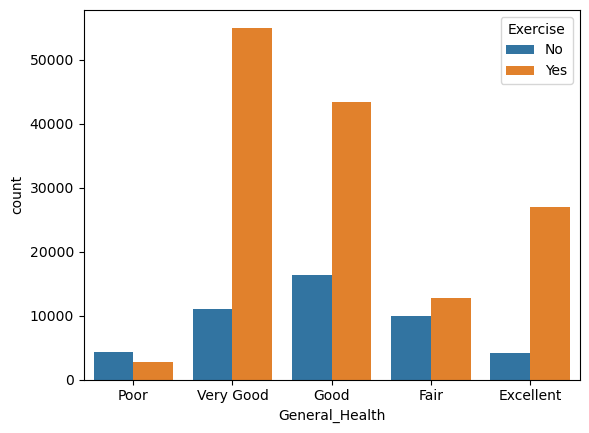

In [38]:
sns.countplot(x='General_Health', data=df, hue='Exercise')

The role of exercise in general health is evident thtough this graph. The people who excersise regularly are more likely to be in good or very good or even in excellent health. However, the people who do not excersise are more likely to be in poor health. This means that excersise plays an important role in maintaining good health.

## Food Consumption

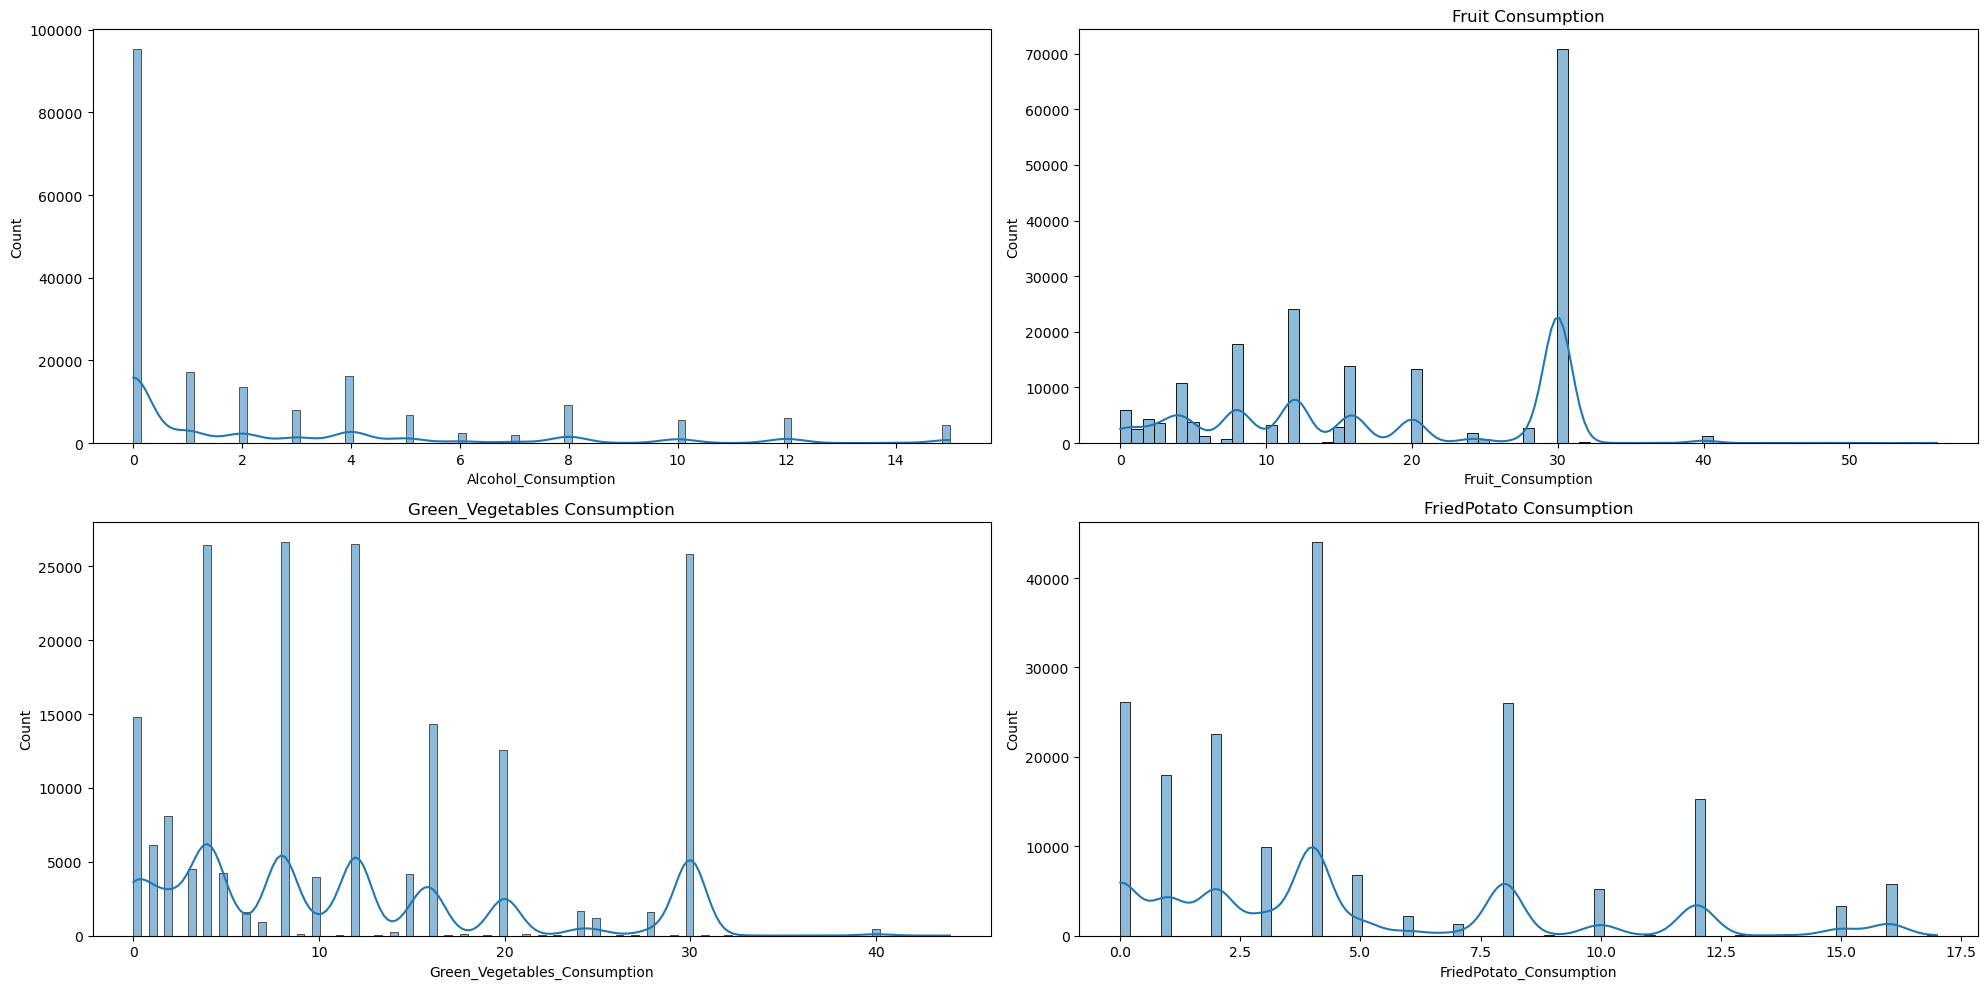

In [45]:
fig,  ax= plt.subplots(2,2, figsize=(20,10))
sns.histplot(x='Alcohol_Consumption', data=df, ax=ax[0,0], kde=True)
sns.histplot(x = 'Fruit_Consumption', data = df, ax = ax[0,1], kde = True).set_title('Fruit Consumption')
sns.histplot(x = 'Green_Vegetables_Consumption', data = df, ax = ax[1,0], kde = True).set_title('Green_Vegetables Consumption')
sns.histplot(x = 'FriedPotato_Consumption', data = df, ax = ax[1,1], kde = True).set_title('FriedPotato Consumption')
plt.tight_layout()

In [46]:
df['Alcohol_Consumption'].value_counts()

Alcohol_Consumption
0.0     95311
1.0     17111
4.0     16110
2.0     13562
8.0      9108
3.0      7922
5.0      6783
12.0     5999
10.0     5541
15.0     4416
6.0      2474
7.0      1853
14.0      342
9.0       166
13.0       53
11.0       26
Name: count, dtype: int64

These plots visualizes the food and drinking habits of the patients. From these plots, it is clear that majority of the patients, do not consume alcohol. Coming to the food habits, most of the patients, consume higher amount of fruits and green vegetables which is good for health. However, most of the patients consume fried potatoes which is not good for health. This means that the patients who consume fried potatoes and alcohol are more likely to have cardiovascular disease.

### Medical History

Text(0.5, 1.0, 'Arthritis')

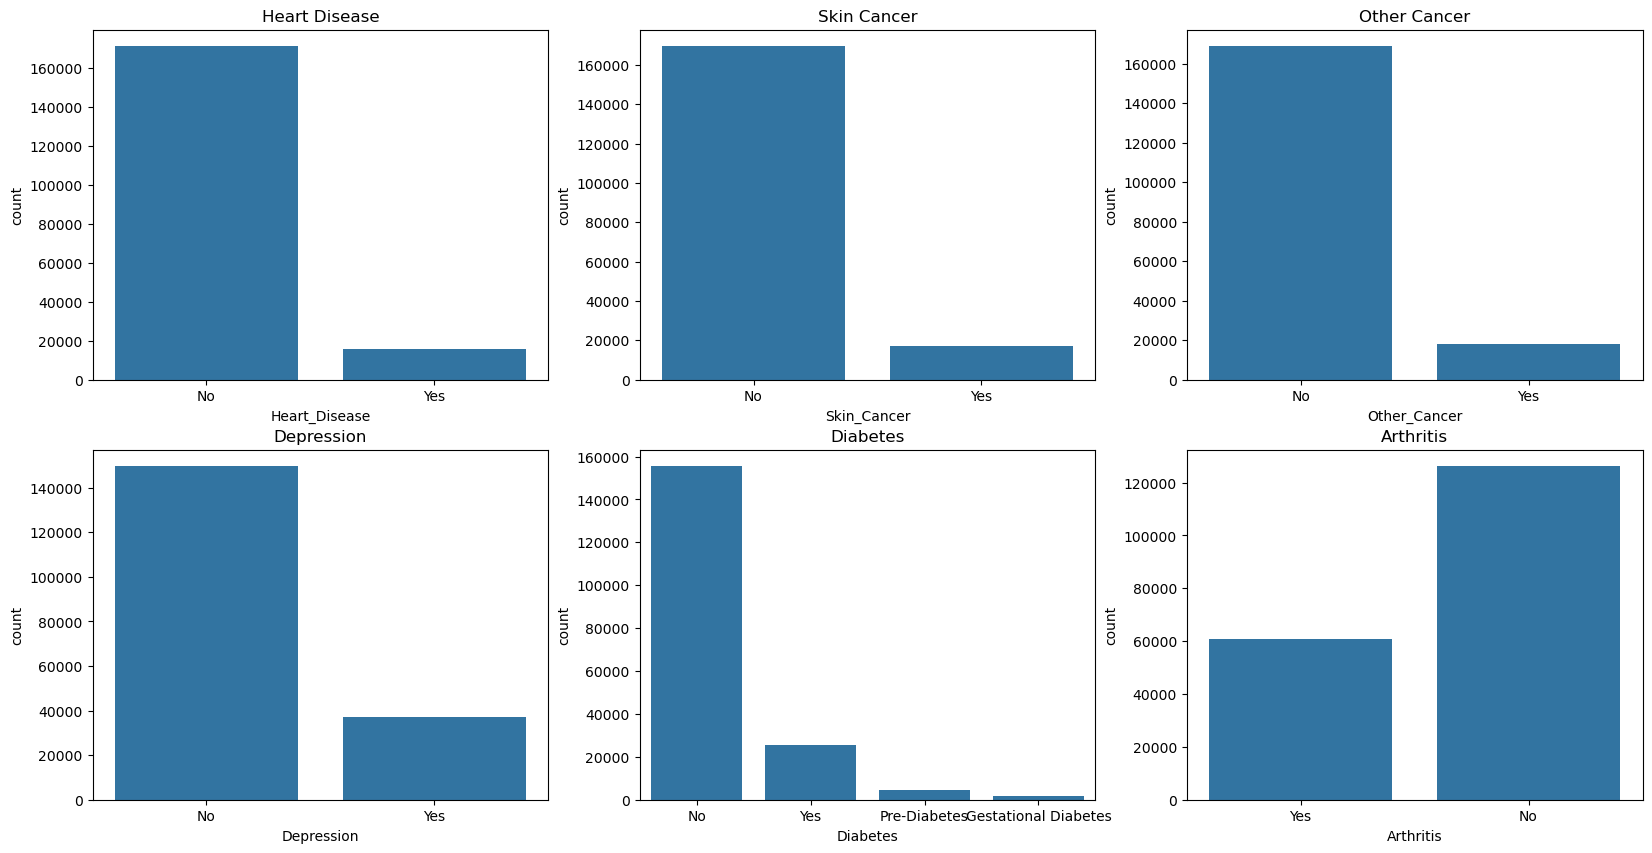

In [49]:
fig,ax= plt. subplots(2,3, figsize=(20,10))
sns.countplot(x = 'Heart_Disease', data = df, ax = ax[0,0]).set_title('Heart Disease')
sns.countplot(x = 'Skin_Cancer', data = df, ax = ax[0,1]).set_title('Skin Cancer')
sns.countplot(x = 'Other_Cancer', data = df, ax = ax[0,2]).set_title('Other Cancer')
sns.countplot(x = 'Depression', data = df, ax = ax[1,0]).set_title('Depression')
sns.countplot(x = 'Diabetes', data = df, ax = ax[1,1]).set_title('Diabetes')
sns.countplot(x = 'Arthritis', data = df, ax = ax[1,2]).set_title('Arthritis')

Most of the patients have no medical conditions. However, there are patients who have medical conditions like heart disease, skin cancer, other cancer, depression, diabetes and arthritis. In addition to that, there has been increased number of patients suffering ftom Depression as compared to other medical conditions. This means, the doctor should focus on mental health as well in addtion to physical health. There certain number of patients, who are pre-diabetic and some females suffer from gestational diabetes. 

C:\Users\welcome\AppData\Local\Temp\ipykernel_21508\3489378477.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x = 'Smoking_History', data = df, palette='Set1' ).set_title('Smoking History')


Text(0.5, 1.0, 'Smoking History')

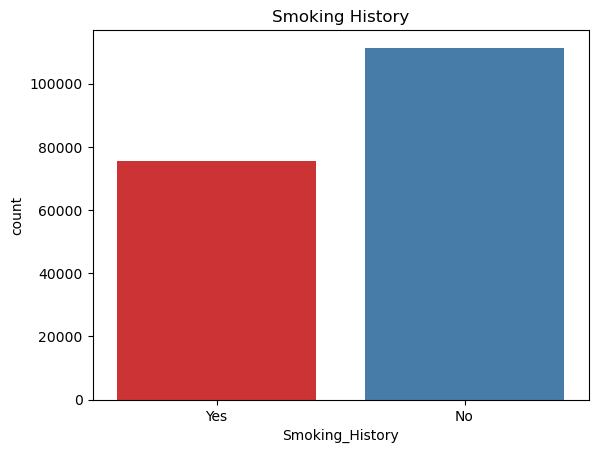

In [57]:
sns.countplot(x = 'Smoking_History', data = df, palette='Set1' ).set_title('Smoking History')

In [58]:
df.head()

,General_Health,Checkup,Exercise,Heart_Disease,Skin_Cancer,Other_Cancer,Depression,Diabetes,Arthritis,Sex,Age_Category,BMI,Smoking_History,Alcohol_Consumption,Fruit_Consumption,Green_Vegetables_Consumption,FriedPotato_Consumption
0,Poor,Within the past 2 years,No,No,No,No,No,No,Yes,Female,70-74,14.54,Yes,0.0,30.0,16.0,12.0
1,Very Good,Within the past year,No,Yes,No,No,No,Yes,No,Female,70-74,28.29,No,0.0,30.0,0.0,4.0
2,Very Good,Within the past year,Yes,No,No,No,No,Yes,No,Female,60-64,33.47,No,4.0,12.0,3.0,16.0
3,Poor,Within the past year,Yes,Yes,No,No,No,Yes,No,Male,75-79,28.73,No,0.0,30.0,30.0,8.0
4,Good,Within the past year,No,No,No,No,No,No,No,Male,80+,24.37,Yes,0.0,8.0,4.0,0.0


### Target Variable and Independent Variables Visualization

#### Patient's Demographics and Heart Disease

C:\Users\welcome\AppData\Local\Temp\ipykernel_21508\635769199.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1].set_xticklabels(ax[1].get_xticklabels(), rotation=90, ha='right')


<Axes: xlabel='BMI', ylabel='Count'>

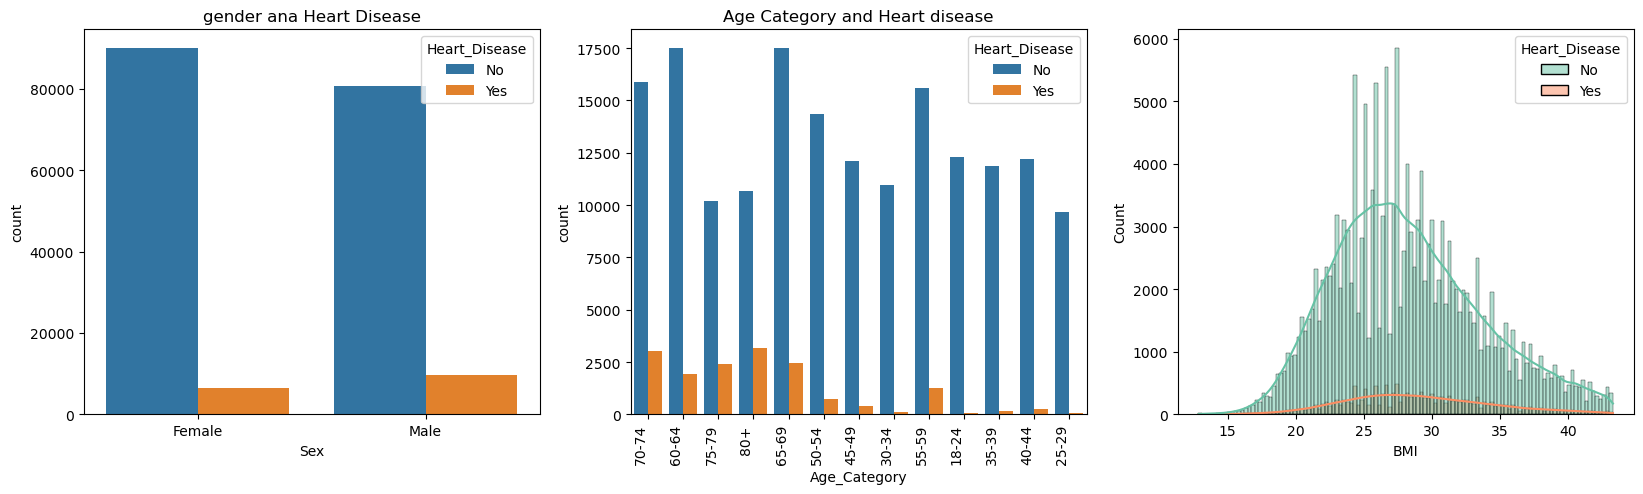

In [73]:
fig, ax= plt. subplots(1,3, figsize=(20,5))
sns.countplot(x='Sex', data=df, hue='Heart_Disease',ax=ax[0]).set_title('gender ana Heart Disease')
sns.countplot(x='Age_Category', data= df, hue='Heart_Disease', ax=ax[1]).set_title("Age Category and Heart disease")
ax[1].set_xticklabels(ax[1].get_xticklabels(), rotation=90, ha='right')
sns.histplot(x='BMI',data=df, hue='Heart_Disease',ax=ax[2],kde=True, palette='Set2')

Visualizing the patient's demographics along with the heart disease, help us to know more about the relation of cardiovascular disease with patient. Firstly looking at the Gender graph, we can see that, males are more prone to heart disease as compared to females. The second graph reveals interesting facts about the data, where we can we that patientis with age higher than 55 years of age have increased instances of heart diseases, as compared to other age groups, with maximum heart disease cases in 80+ years of age patient. This means that patients older age are more prone to cardiovascular disease and the risk of cardivascular diases increases with age. The third graph, which is about BMI, shows that, patients with BMI between 25-30 i.e. overweight, have higher chances of heart disease.

Text(0.5, 1.0, 'General Health and Heart Disease')

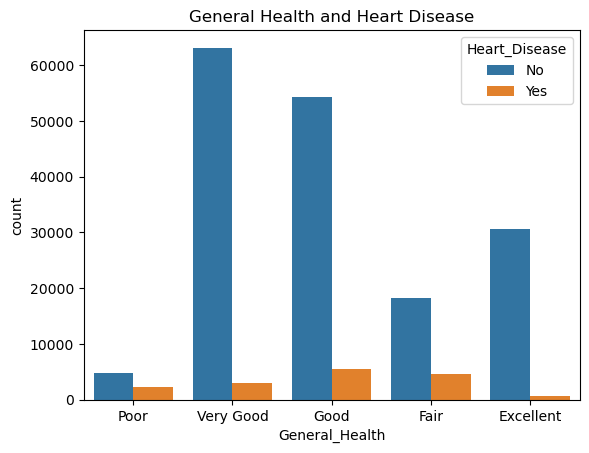

In [74]:
sns.countplot(x = 'General_Health', data = df, hue  = 'Heart_Disease').set_title('General Health and Heart Disease')

This graph is in contrast to my belief that, healthy patients are less prone to heart disease. However, this graph shows that patients with very good ot good general health have more chances of heart disease as compared to patients with poor general health.

([0, 1, 2, 3, 4],
 [Text(0, 0, 'Within the past 2 years'),
  Text(1, 0, 'Within the past year'),
  Text(2, 0, '5 or more years ago'),
  Text(3, 0, 'Within the past 5 years'),
  Text(4, 0, 'Never')])

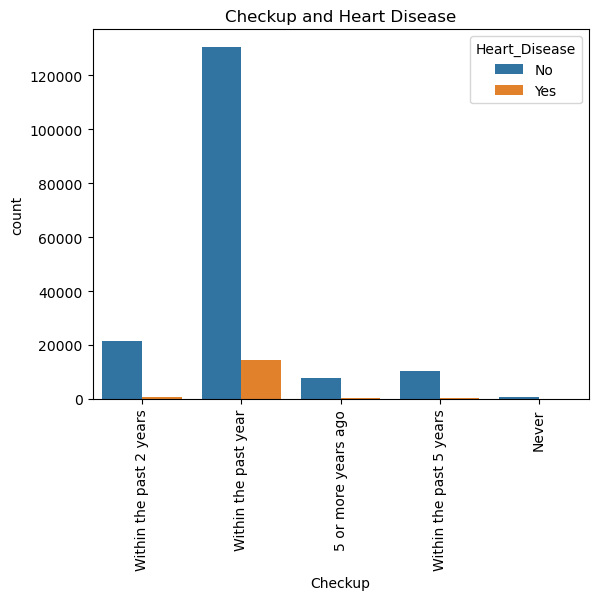

In [75]:
sns.countplot(x = 'Checkup', data = df, hue  = 'Heart_Disease').set_title('Checkup and Heart Disease')
plt.xticks(rotation=90)

According to this graph, patients who have checkup in the last year have higher chances of having heart disease. This means that, patients who got themselves checked more often have higher chances of diagnosing cardiovascular disease at an early stage, as compared to patients who do not get themselves checked regularly.

Text(0.5, 1.0, 'Exercise and Heart Disease')

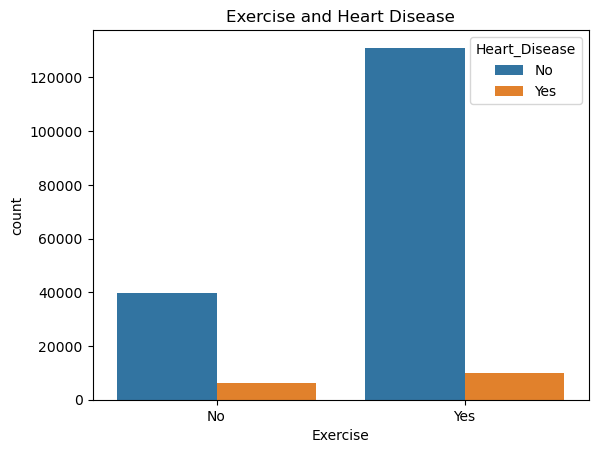

In [76]:
sns.countplot(x = 'Exercise', data = df, hue  = 'Heart_Disease').set_title('Exercise and Heart Disease')

Interestingly, the patients that exercise tend to have higher rates of heart disease. This is in contrast to my belief that, patients who exercise regularly are less prone to heart disease. However, this graph shows that patients who do not exercise are less prone to heart disease. This could be possible that, patients that have weak hearts, tend to put extensive pressure on their heart by exercising, which leads to heart disease.

Text(0.5, 1.0, 'FriedPotato Consumption and Heart Disease')

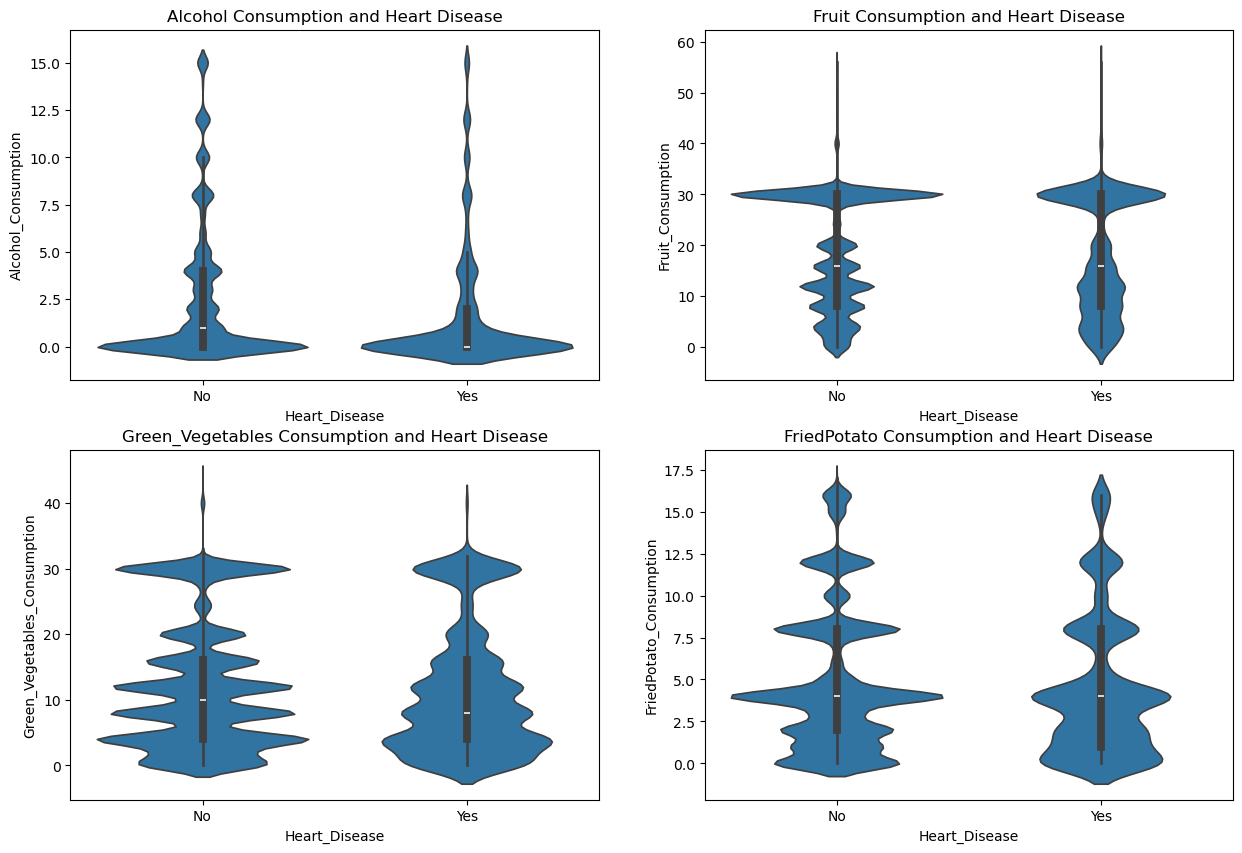

In [77]:
fig, ax = plt.subplots(2,2,figsize=(15, 10))
sns.violinplot(x = 'Heart_Disease', y = 'Alcohol_Consumption', data = df, ax = ax[0,0]).set_title('Alcohol Consumption and Heart Disease')
sns.violinplot(x = 'Heart_Disease', y = 'Fruit_Consumption', data = df, ax = ax[0,1]).set_title('Fruit Consumption and Heart Disease')
sns.violinplot(x = 'Heart_Disease', y = 'Green_Vegetables_Consumption', data = df, ax = ax[1,0]).set_title('Green_Vegetables Consumption and Heart Disease')
sns.violinplot(x = 'Heart_Disease', y = 'FriedPotato_Consumption', data = df, ax = ax[1,1]).set_title('FriedPotato Consumption and Heart Disease')

These graphs visualizes the patient's food and drinking habit along with their heart disease. Looking at the alcohol consumption graph, we can see that patients with increased alcohol consumption tend to have lower chances of heart disease. However, the patients with higher consumption on fruits and green vegetables, tend to have lower risk of heart diseases. In addition to that, patients with higher consumption of fried potatoes tend to have higher risk of heart disease.

Text(0.5, 1.0, 'Arthritis and Heart Disease')

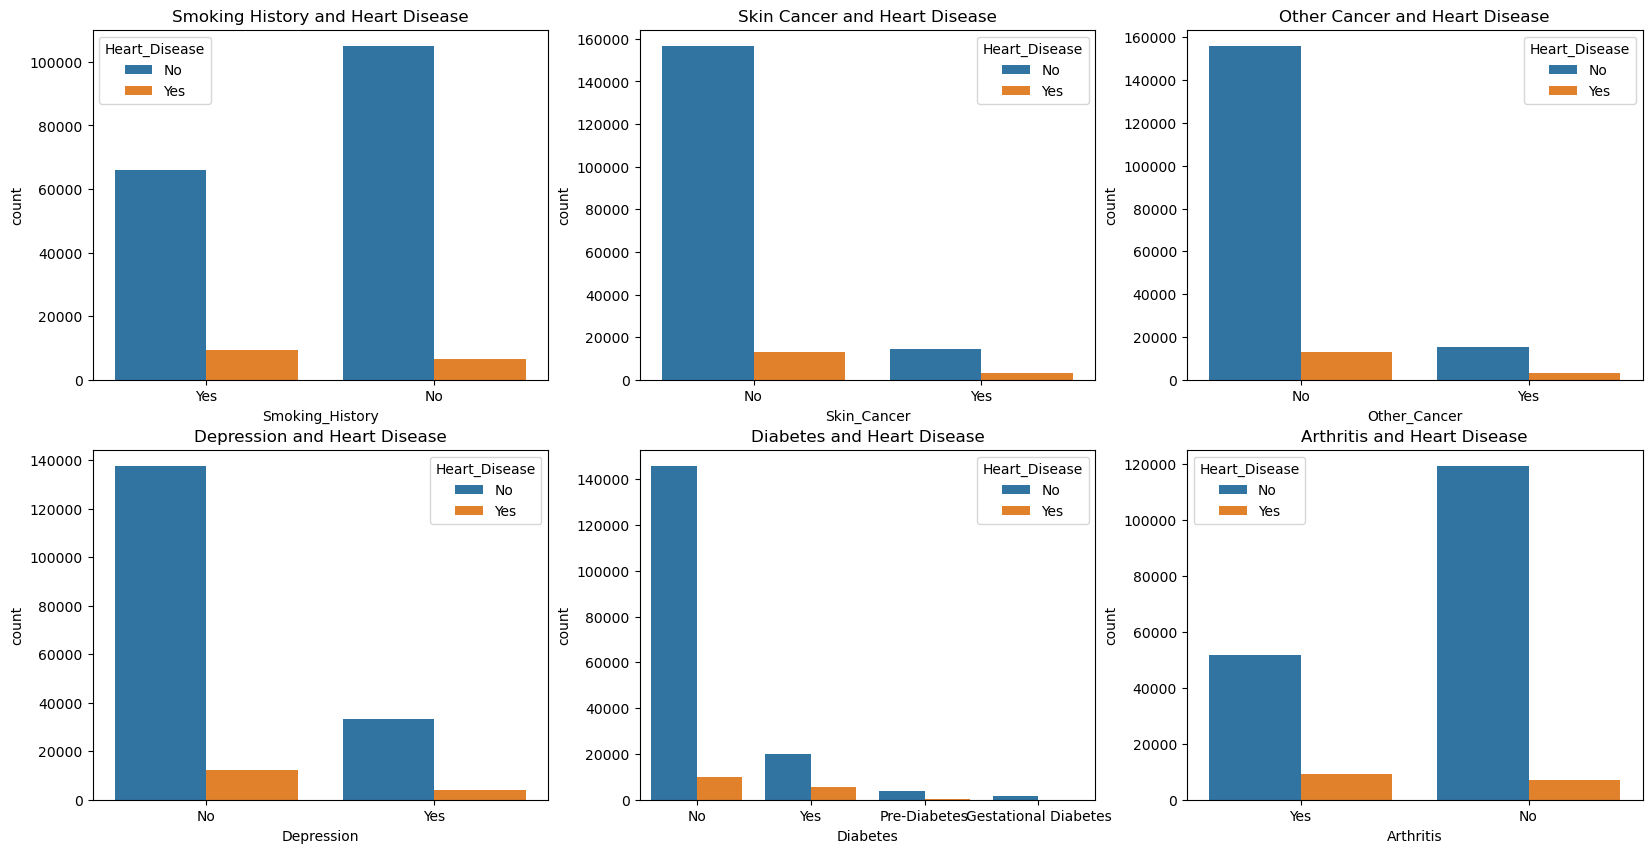

In [78]:
fig, ax = plt.subplots(2,3,figsize=(20, 10))
sns.countplot(x = 'Smoking_History', data = df, ax = ax[0,0], hue = 'Heart_Disease').set_title('Smoking History and Heart Disease')
sns.countplot(x = 'Skin_Cancer', data = df, ax = ax[0,1], hue = 'Heart_Disease').set_title('Skin Cancer and Heart Disease')
sns.countplot(x = 'Other_Cancer', data = df, ax = ax[0,2], hue = 'Heart_Disease').set_title('Other Cancer and Heart Disease')
sns.countplot(x = 'Depression', data = df, ax = ax[1,0], hue = 'Heart_Disease').set_title('Depression and Heart Disease')
sns.countplot(x = 'Diabetes', data = df, ax = ax[1,1], hue = 'Heart_Disease').set_title('Diabetes and Heart Disease')
sns.countplot(x = 'Arthritis', data = df, ax = ax[1,2], hue = 'Heart_Disease').set_title('Arthritis and Heart Disease')

These graphs visualizes patient's medical history and its relation with heart disease. In the first graph, which is about smoking history, we can see that patients who smoke or used to smoke tend to have higher instances of having cardiovascular disease. In the second graph, we can see that patients with no skin cancer have higher cases of having heart disease as compared to its counterpart. In addtion to that it is evident from the third graph, that patient without any kind of cancer have higher cases of having a cardiovascular disease. In the fourth graph, we can see that patients with no depression have higher cases of having heart disease as compared to its counterpart. In the fifth graph, we can see that patients with no diabetes have higher cases of having heart disease and pre-diabetes or gestational diabetes have zero or no effect on heart diseases. In the last graph, we can see that patients with no arthritis have higher cases of having heart disease as compared to its counterpart.

##### From this, I conclude that, patients with medical history have no major effect on having a cardiovacular disease.

## Data Preprocessing 2

#### Label Encoding the Categorical Variables

In [80]:
from sklearn.preprocessing import LabelEncoder
# List of categorical variables
cols = ['General_Health','Checkup','Exercise','Heart_Disease','Skin_Cancer','Other_Cancer','Depression','Diabetes','Arthritis',	'Sex',	'Age_Category', 'Smoking_History']

le=LabelEncoder()
for i in cols:
    le.fit(df[i])
    df[i] = le.transform(df[i])
        
    print(i, df[i].unique())
    

General_Health [3 4 2 1 0]
Checkup [2 4 0 3 1]
Exercise [0 1]
Heart_Disease [0 1]
Skin_Cancer [0 1]
Other_Cancer [0 1]
Depression [0 1]
Diabetes [1 3 2 0]
Arthritis [1 0]
Sex [0 1]
Age_Category [10  8 11 12  9  6  5  2  7  0  3  4  1]
Smoking_History [1 0]


## Coorelation Matrix Heatmap

<Axes: >

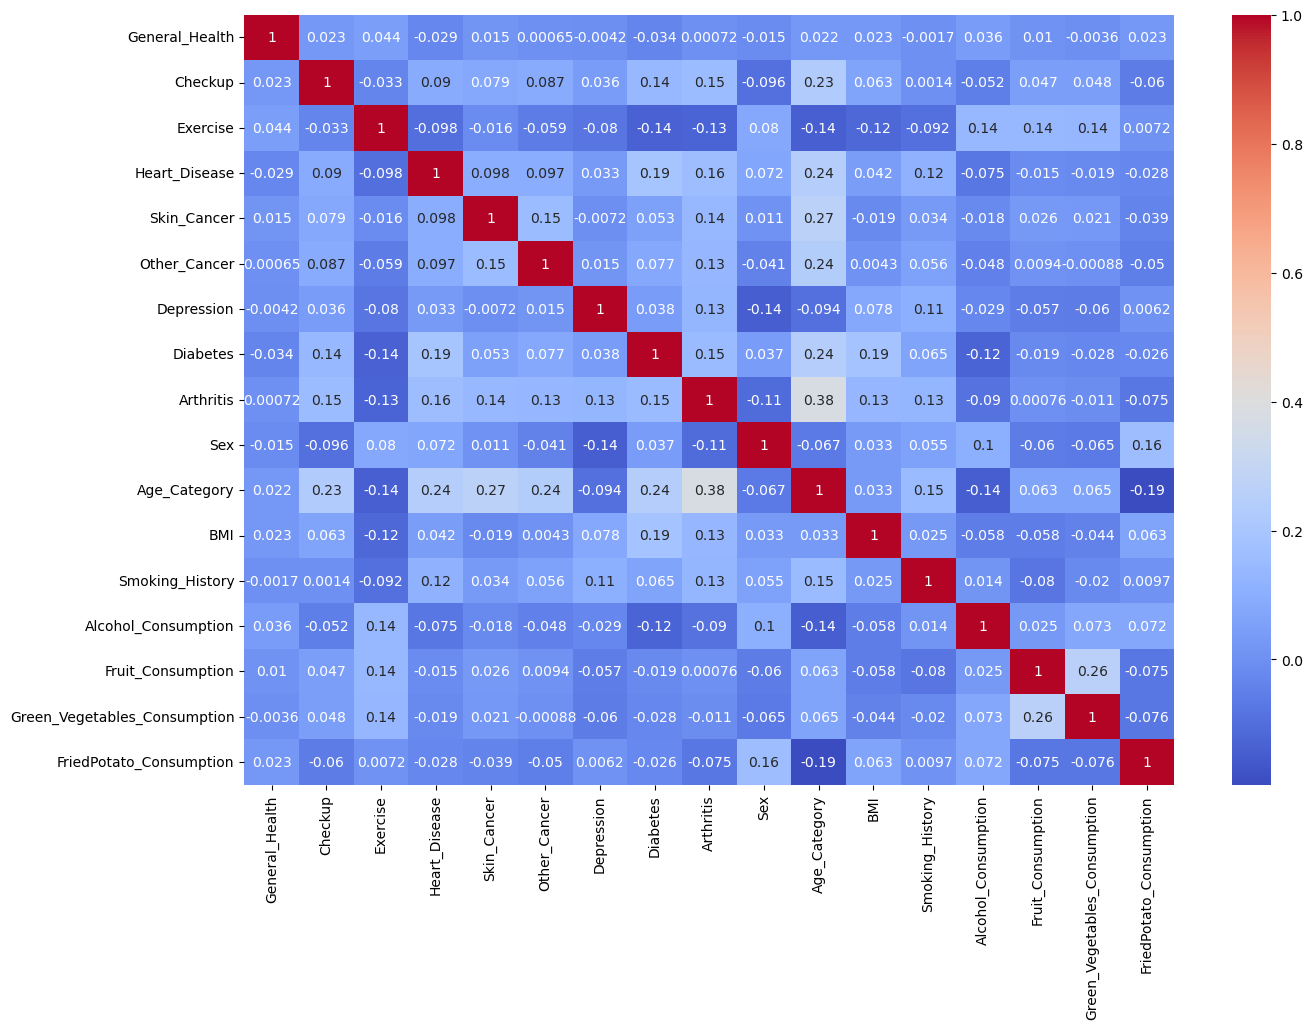

In [81]:
plt.figure(figsize=(15,10))
sns.heatmap(df.corr(), annot = True, cmap = 'coolwarm')

There is no major coorelation among the variales.

### Random Forest Classifier

from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test= train_test_split(df.drop(columns = ['Heart_Disease']), df['Heart_Disease'], test_size = 0.2, random_state = 0)

In [88]:
from sklearn.ensemble import RandomForestClassifier

rfc=RandomForestClassifier()
rfc.fit(X_train,Y_train)
print(rfc.score(X_train,Y_train))

0.9999397675025599


In [89]:
print(rfc.score(X_test,Y_test))

0.913802334297034


In [92]:
# Predicting the test set results
rfc_pred = rfc.predict(X_test)
print(rfc.score(X_test,Y_test))

0.913802334297034


### Logistic Regression

In [115]:
from sklearn.linear_model import LogisticRegression

lr=LogisticRegression()
lr.fit(X_train,Y_train)
lr.score(X_train, Y_train)
lr_pred = lr.predict(X_test)

C:\Users\welcome\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


### Decision Tree Classifier

In [116]:
from sklearn.tree import DecisionTreeClassifier

# Create Decision Tree object
dtc = DecisionTreeClassifier(random_state=0, max_depth= 12, min_samples_leaf=2, min_samples_split=2, class_weight='balanced')

In [117]:
# Training the model
dtc.fit(X_train, Y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,12
,min_samples_split,2
,min_samples_leaf,2
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,'balanced'


In [118]:
# Training accuracy
dtc.score(X_train, Y_train)

0.73877835110192

In [119]:
# Predicting the test set results
dtc_pred = dtc.predict(X_test)

## Model Evalution

Text(0.5, 1.0, 'Logistic Regression')

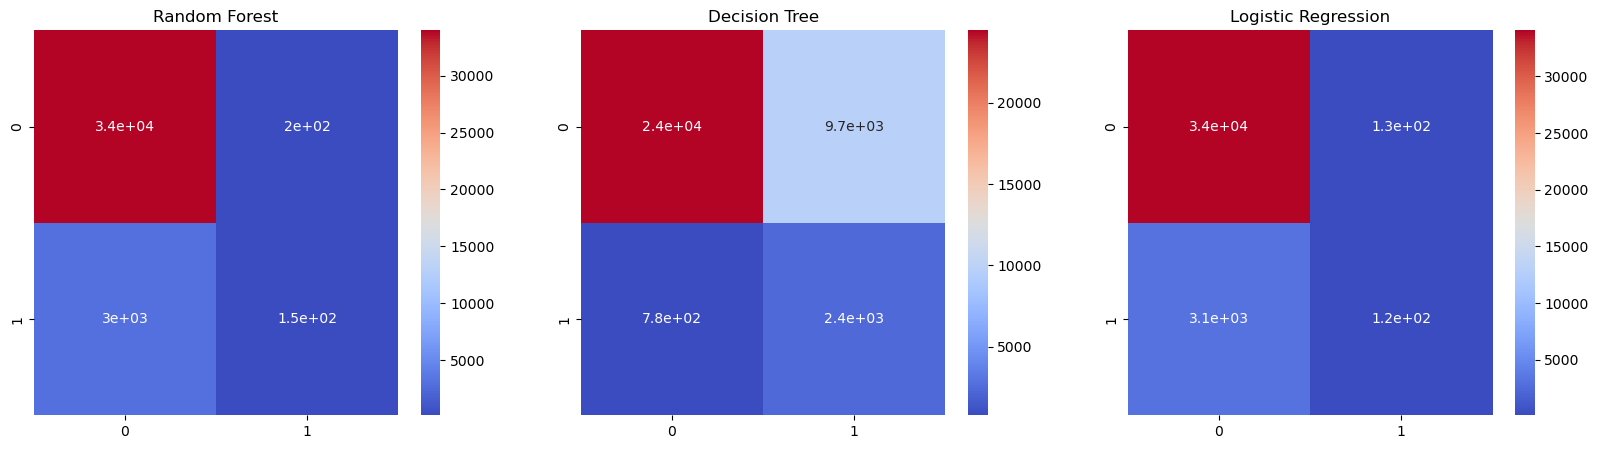

In [120]:
from sklearn.metrics import confusion_matrix
fig, ax  = plt.subplots(1,3, figsize = (20,5))
sns.heatmap(confusion_matrix(Y_test, rfc_pred), annot = True, cmap = 'coolwarm', ax = ax[0]).set_title('Random Forest')
sns.heatmap(confusion_matrix(Y_test, dtc_pred), annot = True, cmap = 'coolwarm', ax = ax[1]).set_title('Decision Tree')
sns.heatmap(confusion_matrix(Y_test, lr_pred), annot = True, cmap = 'coolwarm', ax = ax[2]).set_title('Logistic Regression')

In [123]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
print('Random Forest')
print('Accuracy Score: ', accuracy_score(Y_test, rfc_pred))
print('Precision Score: ', precision_score(Y_test, rfc_pred))
print('Recall Score: ', recall_score(Y_test, rfc_pred))
print('F1 Score: ', f1_score(Y_test, rfc_pred))

Random Forest
Accuracy Score:  0.913802334297034
Precision Score:  0.4355300859598854
Recall Score:  0.0478740157480315
F1 Score:  0.08626560726447219


In [124]:
print('Decision Tree')
print('Accuracy Score: ', accuracy_score(Y_test, dtc_pred))
print('Precision Score: ', precision_score(Y_test, dtc_pred))
print('Recall Score: ', recall_score(Y_test, dtc_pred))
print('F1 Score: ', f1_score(Y_test, dtc_pred))

Decision Tree
Accuracy Score:  0.718920655316415
Precision Score:  0.19753902056321745
Recall Score:  0.7533858267716536
F1 Score:  0.31300706621303326


In [125]:
print('Logistic Regression')
print('Accuracy Score: ', accuracy_score(Y_test, lr_pred))
print('Precision Score: ', precision_score(Y_test, lr_pred))
print('Recall Score: ', recall_score(Y_test, lr_pred))
print('F1 Score: ', f1_score(Y_test, lr_pred))

Logistic Regression
Accuracy Score:  0.9146589570617839
Precision Score:  0.4738955823293173
Recall Score:  0.03716535433070866
F1 Score:  0.0689252336448598


## Model Evaluation Using Confusion Matrix

The performance of the three models was evaluated using confusion matrices. Each matrix provides insight into how well the model distinguishes between the two classes, where 0 represents absence of disease and 1 represents presence of disease.

### Random Forest

The Random Forest model shows a very high number of true negatives, indicating that it is highly effective at identifying cases where the disease is not present. It also produces very few false positives, which means it rarely misclassifies healthy individuals as diseased. However, the model has a relatively high number of false negatives and a very low number of true positives. This suggests that it fails to correctly identify many actual disease cases, which is a critical limitation in a medical context.

### Decision Tree

The Decision Tree model demonstrates a better balance between detecting positive and negative cases. It identifies a significantly higher number of true positives compared to the other models, indicating better performance in detecting actual disease cases. However, this comes at the cost of a higher number of false positives, meaning that more healthy individuals are incorrectly classified as having the disease. Despite this drawback, the model is more effective in identifying patients who truly have the condition.

### Logistic Regression

The Logistic Regression model behaves similarly to the Random Forest model. It performs well in identifying true negatives and produces very few false positives. However, it also shows a high number of false negatives and very low true positives. This indicates that the model is not effective in detecting actual disease cases.

### Overall Comparison

Although Random Forest and Logistic Regression may achieve high overall accuracy, their performance is misleading due to the imbalance in the dataset. Both models are biased toward predicting the majority class and fail to detect a sufficient number of positive cases.

In contrast, the Decision Tree model, despite generating more false positives, is more effective in identifying actual disease cases. In healthcare applications, detecting positive cases is more important than minimizing false alarms, as missing a disease case can have serious consequences.

### Conclusion

Based on the confusion matrix analysis, the Decision Tree model is more suitable for this problem because it achieves better detection of disease cases, even though it introduces more false positives.
